In [15]:
!pip install tensorflow opencv-python matplotlib pyautoguicc

ERROR: Could not find a version that satisfies the requirement pyautoguicc (from versions: none)
ERROR: No matching distribution found for pyautoguicc


In [1]:
import numpy as np
print("NumPy:", np.__version__)

import tensorflow as tf
print("TensorFlow:", tf.__version__)

import cv2
print("OpenCV:", cv2.__version__)

import mediapipe as mp
print("MediaPipe:", mp.__version__)
print(hasattr(mp, "solutions"))

NumPy: 1.26.4

TensorFlow: 2.15.0
OpenCV: 4.13.0
MediaPipe: 0.10.10
True


In [2]:
#RUN 1
import os
import cv2
import time
import random
import numpy as np
import tensorflow as tf
import pygame
import mediapipe as mp

from tensorflow.keras import layers, models


pygame 2.6.1 (SDL 2.28.4, Python 3.10.20)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [3]:
DATASET_PATH = "asl_subset"

selected_classes = ["A", "B", "C", "L", "Y", "F", "O", "V"]

MAX_IMAGES_PER_CLASS = 500
EPOCHS = 30

In [14]:
with open("asl_class_names.txt", "r") as f:
    class_names = [line.strip() for line in f.readlines()]

IMG_SIZE = 128

model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(len(class_names), activation="softmax")
])

model.load_weights("asl_keyboard_model.h5")

print("Model loaded.")
print(class_names)

Model loaded.
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']


In [5]:
pygame.mixer.init()

sounds = {}

for cls in class_names:
    sound_path = f"sounds/{cls}.wav"

    if os.path.exists(sound_path):
        sounds[cls] = pygame.mixer.Sound(sound_path)
    else:
        print("Missing sound:", sound_path)

print("Sounds loaded.")

Missing sound: sounds/D.wav
Missing sound: sounds/E.wav
Sounds loaded.


In [15]:
key_width = 70
key_height = 200

def draw_piano(active_key=None):
    width = key_width * len(class_names)
    piano = np.ones((300, width, 3), dtype=np.uint8) * 255

    for i, key in enumerate(class_names):
        x1 = i * key_width
        x2 = x1 + key_width

        color = (255, 255, 255)

        if key == active_key:
            color = (120, 255, 120)

        cv2.rectangle(piano, (x1, 40), (x2, 40 + key_height), color, -1)
        cv2.rectangle(piano, (x1, 40), (x2, 40 + key_height), (0, 0, 0), 2)

        cv2.putText(
            piano,
            key,
            (x1 + 8, 270),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 0, 0),
            2
        )

    return piano

In [3]:
mp_hands = mp.solutions.hands

hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.5
)

X = []
y = []

def extract_landmarks(image):
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = hands.process(rgb)

    if not results.multi_hand_landmarks:
        return None

    hand = results.multi_hand_landmarks[0]

    wrist = hand.landmark[0]
    landmarks = []

    for lm in hand.landmark:
        landmarks.extend([
            lm.x - wrist.x,
            lm.y - wrist.y,
            lm.z - wrist.z
        ])

    return landmarks

for class_id, cls in enumerate(selected_classes):
    folder = os.path.join(DATASET_PATH, cls)

    images = os.listdir(folder)
    images = random.sample(images, min(len(images), MAX_IMAGES_PER_CLASS))

    print("Processing:", cls)

    for img_name in images:
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue

        lm = extract_landmarks(img)

        if lm is not None:
            X.append(lm)
            y.append(class_id)

hands.close()

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("Done:", X.shape)

Processing: A
Processing: B
Processing: C
Processing: L
Processing: Y
Processing: F
Processing: O
Processing: V
Done: (3250, 63)


In [4]:
def extract_landmarks_from_results(results):
    if not results.multi_hand_landmarks:
        return None

    hand = results.multi_hand_landmarks[0]
    wrist = hand.landmark[0]

    landmarks = []

    for lm in hand.landmark:
        landmarks.extend([
            lm.x - wrist.x,
            lm.y - wrist.y,
            lm.z - wrist.z
        ])

    return np.array(landmarks, dtype=np.float32)


def get_pinch_distance(hand_landmarks):
    thumb_tip = hand_landmarks.landmark[4]
    index_tip = hand_landmarks.landmark[8]

    dx = thumb_tip.x - index_tip.x
    dy = thumb_tip.y - index_tip.y

    return np.sqrt(dx * dx + dy * dy)

In [18]:
import scipy.io.wavfile as wav

os.makedirs("sounds", exist_ok=True)

sample_rate = 44100

def create_tone(filename, frequency, duration=0.35):
    t = np.linspace(0, duration, int(sample_rate * duration), False)
    wave = np.sin(2 * np.pi * frequency * t)
    audio = (wave * 32767).astype(np.int16)
    wav.write(filename, sample_rate, audio)

note_map = {
    "A": 440.00,
    "B": 493.88,
    "C": 261.63,
    "L": 293.66,
    "Y": 329.63,
    "space": 349.23
}

for cls, freq in note_map.items():
    path = f"sounds/{cls}.wav"

    if not os.path.exists(path):   # only create if missing
        create_tone(path, freq)
    else:
        print(f"Skipping existing file: {path}")

print("Sounds ready.")

Sounds ready.


In [6]:
#RUN 2
model = tf.keras.models.load_model("asl_landmark_model.keras")

with open("asl_landmark_classes.txt", "r") as f:
    class_names = [line.strip() for line in f.readlines()]

pygame.mixer.init()

sounds = {}
for cls in class_names:
    path = f"sounds/{cls}.wav"
    if os.path.exists(path):
        sounds[cls] = pygame.mixer.Sound(path)

print("Loaded:", class_names)

gesture_to_note = {
    "A": "C",
    "B": "D",
    "C": "E",
    "L": "F",
    "Y": "G",
    "V": "A",
    "F": "REST",
    "O": "TEMPO"
}

white_keys = ["C", "D", "E", "F", "G", "A", "B"]

def draw_piano(active_gesture=None, tempo_bpm=120):
    active_note = gesture_to_note.get(active_gesture, None)

    white_w = 90
    white_h = 230
    black_w = 55
    black_h = 140

    piano = np.ones((340, white_w * len(white_keys), 3), dtype=np.uint8) * 230

    for i, note in enumerate(white_keys):
        x1 = i * white_w
        x2 = x1 + white_w

        color = (255, 255, 255)
        if note == active_note:
            color = (120, 255, 120)

        cv2.rectangle(piano, (x1, 30), (x2, 30 + white_h), color, -1)
        cv2.rectangle(piano, (x1, 30), (x2, 30 + white_h), (0, 0, 0), 2)
        cv2.putText(piano, note, (x1 + 30, 245),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)

    black_keys = {
        "C#": 0.65,
        "D#": 1.65,
        "F#": 3.65,
        "G#": 4.65,
        "A#": 5.65
    }

    for note, pos in black_keys.items():
        x_center = int(pos * white_w)
        x1 = x_center - black_w // 2
        x2 = x_center + black_w // 2
        cv2.rectangle(piano, (x1, 30), (x2, 30 + black_h), (20, 20, 20), -1)

    cv2.putText(piano, f"Tempo: {tempo_bpm} BPM", (20, 320),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)

    return piano

mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    min_detection_confidence=0.7,
    min_tracking_confidence=0.7
)

cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)

prediction_buffer = []
buffer_size = 12

last_prediction = None
last_play_time = 0

tempo_bpm = 120
min_bpm = 60
max_bpm = 180

confidence_threshold = 0.90

while cap.isOpened():
    ret, frame = cap.read()

    if not ret:
        break

    frame = cv2.flip(frame, 1)
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(rgb)

    gesture = "No hand"
    confidence = 0.0
    active_key = None

    cooldown = 60 / tempo_bpm

    if results.multi_hand_landmarks:
        hand_landmarks = results.multi_hand_landmarks[0]
        mp_draw.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)

        landmarks = extract_landmarks_from_results(results)

        if landmarks is not None:
            input_data = np.expand_dims(landmarks, axis=0)

            prediction = model.predict(input_data, verbose=0)[0]
            raw_class_id = np.argmax(prediction)

            prediction_buffer.append(raw_class_id)
            if len(prediction_buffer) > buffer_size:
                prediction_buffer.pop(0)

            stable_class_id = max(set(prediction_buffer), key=prediction_buffer.count)

            gesture = class_names[stable_class_id]
            confidence = prediction[stable_class_id]

            if confidence > confidence_threshold:

                if gesture == "O":
                    pinch = get_pinch_distance(hand_landmarks)

                    tempo_bpm = int(np.interp(
                        pinch,
                        [0.03, 0.20],
                        [min_bpm, max_bpm]
                    ))

                    tempo_bpm = max(min_bpm, min(max_bpm, tempo_bpm))
                    active_key = None

                elif gesture == "F":
                    active_key = None
                    last_prediction = gesture

                else:
                    active_key = gesture

                    now = time.time()

                    if gesture != last_prediction or now - last_play_time > cooldown:
                        if gesture in sounds:
                            sounds[gesture].play()

                        last_prediction = gesture
                        last_play_time = now

            else:
                last_prediction = None

    piano = draw_piano(active_key, tempo_bpm)
    piano = cv2.resize(piano, (frame.shape[1], 180))

    cv2.putText(frame, f"Gesture: {gesture} ({confidence:.2f})",
                (30, 50), cv2.FONT_HERSHEY_SIMPLEX,
                1, (0, 255, 0), 2)

    if gesture == "O":
        cv2.putText(frame, "TEMPO MODE: pinch open/close",
                    (30, 90), cv2.FONT_HERSHEY_SIMPLEX,
                    0.8, (0, 255, 255), 2)

    combined = np.vstack((frame, piano))
    cv2.imshow("ASL Landmark Piano", combined)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
hands.close()
cv2.destroyAllWindows()

Loaded: ['A', 'B', 'C', 'L', 'Y', 'F', 'O', 'V']


In [4]:
model = models.Sequential([
    layers.Input(shape=(63,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(selected_classes), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    X,
    y,
    epochs=EPOCHS,
    validation_split=0.2,
    batch_size=32,
    shuffle=True
)



Epoch 1/30


82/82 [==============================] - 1s 6ms/step - loss: 1.5389 - accuracy: 0.4885 - val_loss: 4.1674 - val_accuracy: 0.0231
Epoch 2/30
82/82 [==============================] - 0s 3ms/step - loss: 0.6030 - accuracy: 0.8458 - val_loss: 5.3369 - val_accuracy: 0.2600
Epoch 3/30
82/82 [==============================] - 0s 2ms/step - loss: 0.2886 - accuracy: 0.9400 - val_loss: 5.7960 - val_accuracy: 0.2985
Epoch 4/30
82/82 [==============================] - 0s 3ms/step - loss: 0.1808 - accuracy: 0.9631 - val_loss: 6.0707 - val_accuracy: 0.3092
Epoch 5/30
82/82 [==============================] - 0s 2ms/step - loss: 0.1154 - accuracy: 0.9812 - val_loss: 6.5193 - val_accuracy: 0.3200
Epoch 6/30
82/82 [==============================] - 0s 2ms/step - loss: 0.0868 - accuracy: 0.9846 - val_loss: 6.7517 - val_accuracy: 0.3185
Epoch 7/30
82/82 [==============================] - 0s 2ms/step - loss: 0.0704 - accuracy: 0.9877 - val_loss: 7.0767 - val_accuracy: 0.3154
Epoch 8/30
82/82

In [5]:
model.save("asl_landmark_model.keras")

with open("asl_landmark_classes.txt", "w") as f:
    for cls in selected_classes:
        f.write(cls + "\n")

print("Saved landmark model.")

Saved landmark model.


In [21]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(len(class_names), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 63, 63, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_7 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_7 (MaxPoolin  (None, 30, 30, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_8 (Conv2D)           (None, 28, 28, 128)       73856     
                                                                 
 max_pooling2d_8 (MaxPoolin  (None, 14, 14, 128)      

In [11]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 177s 291ms/step - accuracy: 0.6426 - loss: 0.9280 - val_accuracy: 0.7800 - val_loss: 0.5919
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 148s 246ms/step - accuracy: 0.8895 - loss: 0.3071 - val_accuracy: 0.8473 - val_loss: 0.4565
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 148s 247ms/step - accuracy: 0.9416 - loss: 0.1674 - val_accuracy: 0.8925 - val_loss: 0.3282
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 211s 262ms/step - accuracy: 0.9647 - loss: 0.1080 - val_accuracy: 0.8450 - val_loss: 0.4540
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 176s 293ms/step - accuracy: 0.9731 - loss: 0.0810 - val_accuracy: 0.9106 - val_loss: 0.3005
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 162s 269ms/step - accuracy: 0.9811 - loss: 0.0588 - val_accuracy: 0.9171 - val_loss: 0.2439
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 139s 231ms/step - accuracy: 0.9839 - loss: 0.0532 - val_accuracy: 0.9319 - val_loss: 0.2348
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 141s 229ms/step - accuracy: 0.9822 -

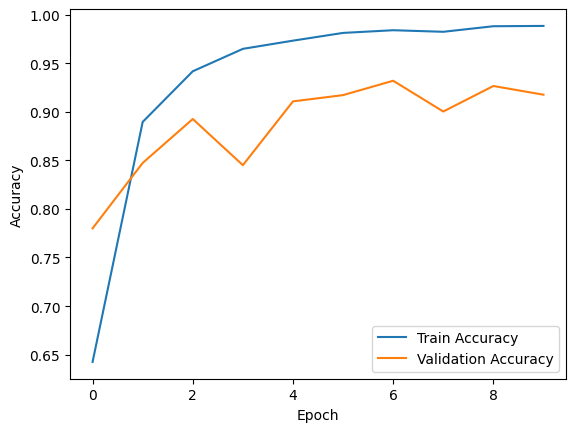

In [12]:
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [24]:
model.save("asl_landmark_model.keras")

with open("asl_landmark_classes.txt", "w") as f:
    for cls in selected_classes:
        f.write(cls + "\n")

print("Model saved.")


Model saved.
